In [5]:
import torch
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker


In [2]:
model_path = r"D:\project\transformer\NLP_transformer\transformer\models\qwen\Qwen2-0___5B"

In [3]:
# 1. 加载模型
model = AutoModelForCausalLM.from_pretrained(model_path, trust_remote_code=True, low_cpu_mem_usage=True)

In [ ]:
# 2. 获取模型的权重并将它们连接成一个张量
weights = []
for param in model.parameters():
    weights.append(param.view(-1))
weights_tensor = torch.cat(weights)

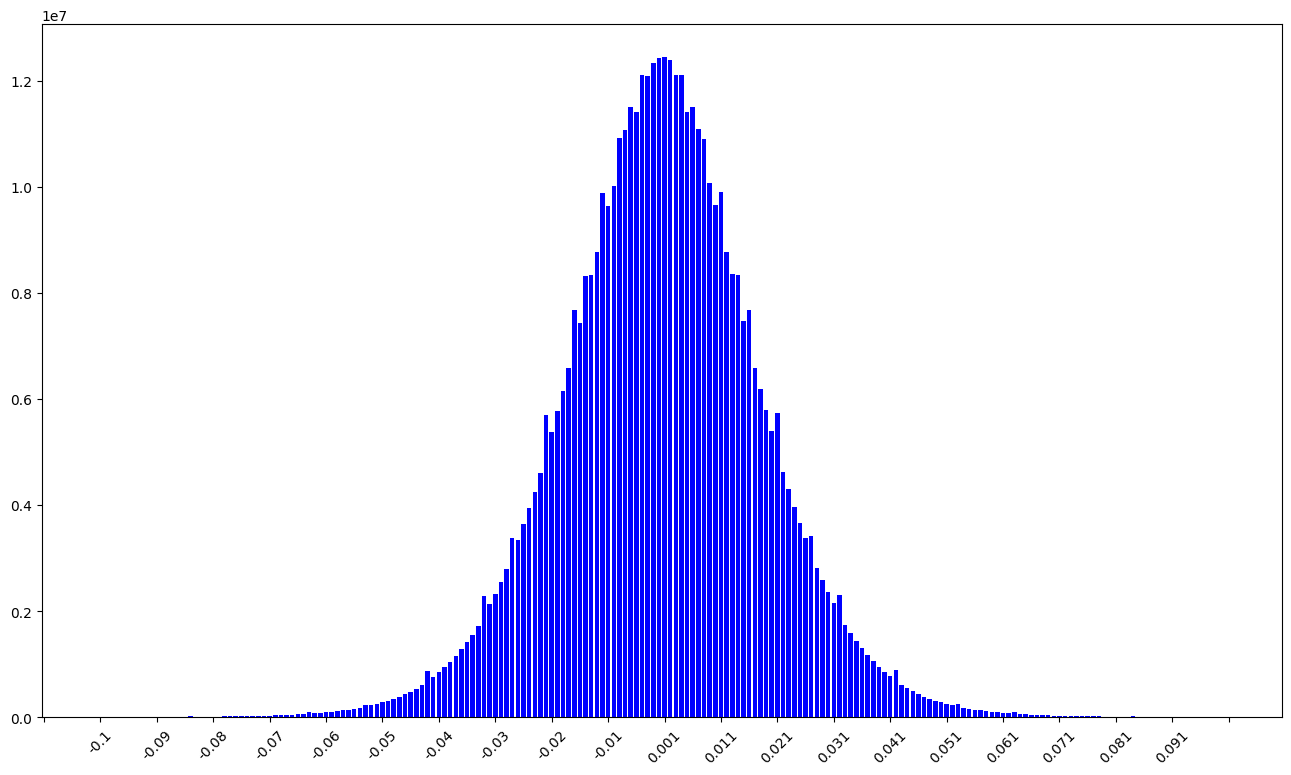

In [9]:
# 3. 使用直方图统计权重的分布情况
bins = 200
hist, _ = torch.histogram(weights_tensor.float(), bins=bins, range=(-0.1, 0.1))

# 4. 绘制权重分布的直方图
plt.figure(figsize=(16, 9))
x = np.arange(bins)
plt.bar(x, hist.detach().numpy(), color="blue")
plt.xticks(x, np.linspace(-0.1, 0.1, 200).round(3), rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.show()
